# Estimation of stopping powers in liquid scintillator

In [14]:
pip install TDCRPy==2.16.14

Note: you may need to restart the kernel to use updated packages.


In [15]:
import tdcrpy as td
import matplotlib.pyplot as plt
import numpy as np

## Stopping power at a given energy

In [16]:
density = 0.96 # in g/cm3
energy = 200 # keV
result_alpha = td.TDCR_model_lib.stoppingpowerA(energy,rho=density)
result_electron = td.TDCR_model_lib.stoppingpower(energy*1e3,rho=density)
print(f"dE/dx = {result_alpha:.7g} keV/cm for alpha particles" )
print(f"dE/dx = {result_electron*1e3:.4g} keV/cm for electrons" )

dE/dx = 1913280 keV/cm for alpha particles
dE/dx = 2319 keV/cm for electrons


## Plot stopping power curves

### For alpha particles

Text(0, 0.5, 'd$E$/d$x$ /(MeV/cm)')

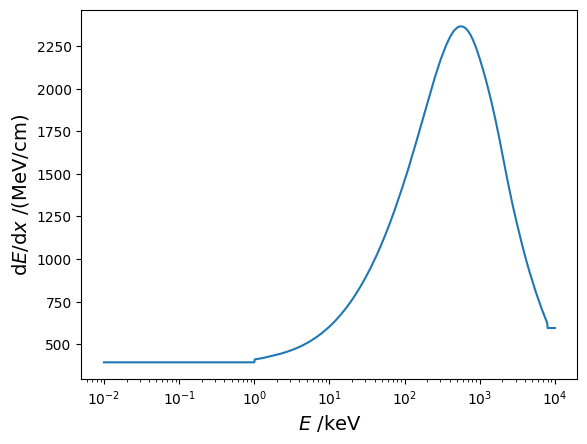

In [17]:
energy_vec = np.logspace(-2,4,1000) # in keV

w_a = []
for e in energy_vec:
        w_a.append(1e-3*td.TDCR_model_lib.stoppingpowerA(e,rho=density))

plt.figure("Stopping power - alpha particles")
plt.clf()
plt.plot(energy_vec,w_a)
plt.xscale('log')
plt.xlabel(r'$E$ /keV', fontsize=14)
plt.ylabel(r'd$E$/d$x$ /(MeV/cm)', fontsize=14)

### For electrons

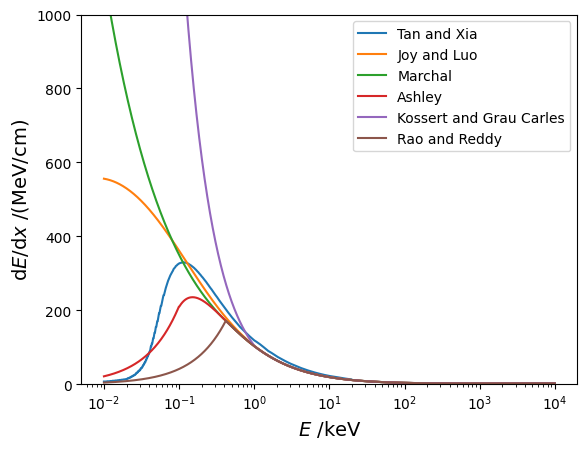

In [18]:
energy_vec = np.logspace(-2,4,1000) # in keV

w_e_tan, w_e_joy, w_e_marchal, w_e_ashley, w_e_kossert, w_e_rao = [], [], [], [], [], []
for e in energy_vec:
        w_a.append(td.TDCR_model_lib.stoppingpowerA(e,rho=density))
        w_e_tan.append(td.TDCR_model_lib.stoppingpower(e*1e3,rho=density))
        w_e_joy.append(td.TDCR_model_lib.stoppingpower(e*1e3,rho=density,spmodel="joy_luo"))
        w_e_marchal.append(td.TDCR_model_lib.stoppingpower(e*1e3,rho=density,spmodel="marchal"))
        w_e_ashley.append(td.TDCR_model_lib.stoppingpower(e*1e3,rho=density,spmodel="ashley"))
        w_e_kossert.append(td.TDCR_model_lib.stoppingpower(e*1e3,rho=density,spmodel="kossert_graucarles"))
        w_e_rao.append(td.TDCR_model_lib.stoppingpower(e*1e3,rho=density,spmodel="rao_reddy"))

plt.figure("Stopping power - electrons")
plt.clf()
plt.plot(energy_vec,w_e_tan,label="Tan and Xia")
plt.plot(energy_vec,w_e_joy,label="Joy and Luo")
plt.plot(energy_vec,w_e_marchal,label="Marchal")
plt.plot(energy_vec,w_e_ashley,label="Ashley")
plt.plot(energy_vec,w_e_kossert,label="Kossert and Grau Carles")
plt.plot(energy_vec,w_e_rao,label="Rao and Reddy")
plt.xscale('log')
plt.ylim([0, 1000])
plt.xlabel(r'$E$ /keV', fontsize=14)
plt.ylabel(r'd$E$/d$x$ /(MeV/cm)', fontsize=14)
plt.legend()